In [21]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_core.messages import HumanMessage, AIMessage, AnyMessage
from langchain.chat_models import init_chat_model
from typing import List, Optional, TypedDict, Annotated
import operator
from dotenv import load_dotenv
from pydantic import BaseModel, Field

# Load environmental variables from .env
load_dotenv()

True

In [22]:
llm = init_chat_model("gpt-4o-mini")


## **Define state and create a graph**

In [23]:
def coalesce(old: Optional[str], new: Optional[str]) -> Optional[str]:
    return new or old

class GState(BaseModel):
    messages: Annotated[list[AnyMessage], operator.add]
    city: Annotated[Optional[str], coalesce] = Field(default=None)
    interests: Annotated[List[str], operator.add] =  Field(description="Short list of interests - 3-5 elements")
    activities: Annotated[List[str], operator.add] = Field(description="List of activities.")
    sights: Annotated[List[str], operator.add] = Field(description="List of interesting places")

graph = StateGraph(GState)



##**Edges**

In [24]:

def collect_preferences(state: GState) -> dict:

    class RespStructure(BaseModel):
        city: str
        interests: Optional[List[str]]

    text = state.messages[-1].content if state.messages else ""
    prompt = f"""
From the user input:
<user_input>
{text}
</user_input>

extract information about the city name and user's interests. Both city and user interests can be empty.
"""
    ai = llm.with_structured_output(RespStructure).invoke(prompt)
    res = {
        "city": ai.city,
        "interests":  ai.interests if ai.interests else []
        }

    return res

def ask_activities(state: GState) -> dict:
    prompt = f"User likes {', '.join(state.interests)}. User will visit: {state.city}. Suggest 3 activities."
    out = llm.invoke(prompt).content.split("\n")
    return {"activities": [x for x in out if x.strip()]}


def ask_sights(state: GState) -> dict:
    prompt = f"Most interesting places to visit in {state.city}: 3 propositions."
    out = llm.invoke(prompt).content.split("\n")
    return {"sights": [x for x in out if x.strip()]}

def ask_both(state: GState) -> GState:
    return state

def ask_for_more(state: GState) -> GState:
    """Fallback node when we don't know city nor interests."""
    msg = AIMessage("Could you tell me which city you're visiting and what you like to do?")
    return state.model_copy(update={"messages": state.messages + [msg]})

def compose_answer(state: GState) -> GState:
    answer = (
        f"### City: {state.city}\n"
        f"### Interests (carry over if city changes): {', '.join(state.interests)}\n"
        f"### Activities:\n- " + "\n- ".join(state.activities) + "\n"
        f"### Locations:\n- " + "\n- ".join(state.sights)
    )
    state.messages = state.messages + [AIMessage(answer)]
    return state



In [25]:
def routing_decision(state: GState) -> str:
    """
    Decide where to go after classification.
    - both city and interests -> go to BOTH 'ask_activities' and 'ask_sights'
      (we will add separate conditional edges for that)
    - only city -> go to 'recommend_sights'
    - only interests -> go to 'recommend_activities'
    - none -> go to 'ask_for_more'
    """
    has_city = state.city is not None and state.city.strip() != ""
    has_interests = len(state.interests) > 0

    if has_city and has_interests:
        return "both"
    elif has_city:
        return "sights"
    elif has_interests:
        return "activities"
    else:
        return "ask"

##Create graph layout

In [26]:
graph.add_node("collect_preferences", collect_preferences)
graph.add_node("ask_activities", ask_activities)
graph.add_node("ask_sights", ask_sights)
graph.add_node("ask_both", ask_both)
graph.add_node("ask_for_more", ask_for_more)
graph.add_node("compose_answer", compose_answer)


graph.set_entry_point("collect_preferences")
graph.add_conditional_edges(
    "collect_preferences",
    routing_decision,
    {
        "both": "ask_both", #["ask_activities", "ask_sights"],  # fan-out
        "sights": "ask_sights",
        "activities": "ask_activities",
        "ask": "ask_for_more",
    },
)
graph.add_edge("ask_both", "ask_activities")
graph.add_edge("ask_both", "ask_sights")
graph.add_edge("ask_activities", "compose_answer")
graph.add_edge("ask_sights", "compose_answer")
graph.add_edge("compose_answer", END)

app = graph.compile()




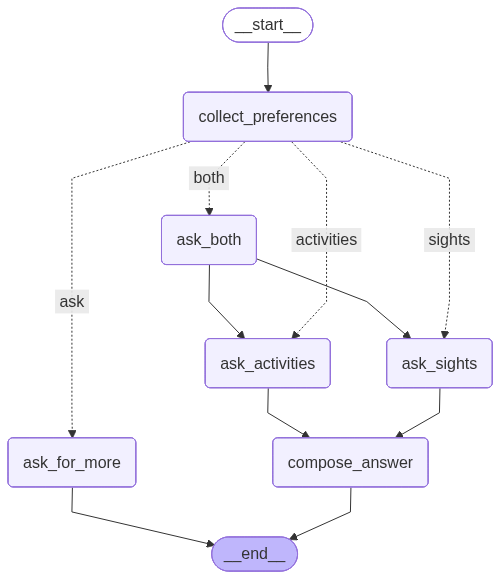

In [27]:
# Show the agent
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [28]:
initial = GState(
    messages = [HumanMessage("I like street food and wine tasting. I will travel to Florence.")],
    city = "",
    interests = [],
    activities = [],
    sights = []
)
final_result1 = app.invoke(initial)
print(final_result1["messages"][-1].content)

both
### City: Florence
### Interests (carry over if city changes): street food, wine tasting, street food, wine tasting
### Activities:
- Florence is a fantastic destination for street food enthusiasts and wine lovers alike. Here are three activities you can enjoy during your visit:
- 1. **Florence Street Food Tour**: Join a guided street food tour to explore the local culinary scene. You'll sample a variety of Tuscan specialties, such as "panino con lampredotto" (a sandwich made with tripe), "schiacciata" (a type of flatbread), and delicious pastries. As you stroll through the vibrant markets and historic streets, your guide will share insights about the city's food culture and history.
- 2. **Wine Tasting in the Chianti Region**: Take a day trip to the nearby Chianti wine region for a wine tasting experience. Many local wineries offer tours that include tastings of their finest Chianti Classico wines, paired with traditional Tuscan snacks. You'll get a chance to learn about the wine

In [29]:
final_result2 = app.invoke(
    {"messages": [HumanMessage("Now I'm going to visit")]}
)
print(final_result2["messages"][-1].content)

ask
Could you tell me which city you're visiting and what you like to do?
